# ESG Data Automation — GHG Emissions Reporting

## Project Overview

This notebook simulates a real-world ESG data pipeline. A company operates three production facilities — **Milano**, **Lione**, and **Roma** — and each plant manager submits a separate Excel file containing the year's resource consumption data. The goal is to **ingest, validate, clean, and consolidate** those files into a single dataset, **calculate greenhouse gas (GHG) emissions**, and produce a **structured, formatted Excel report** ready for sustainability disclosure.

The notebook is organised into four sequential phases:
1. **Data Loading & Exploration**: Import the three raw files and run an initial quality assessment
2. **Data Cleaning**: Standardise, repair, and validate the data before merging
3. **Emissions Calculation**: Apply emission factors to compute kgCO₂e per record
4. **Export & Reporting**: Write a multi-sheet, formatted Excel report

### Repository Structure

```
project/
├── config.py                  # Centralised lookup tables and emission factors
├── notebook.ipynb              # This notebook
└── data/
    └── consumi_milano.xlsx         # Raw input — Milano plant
    └── consumi_lione.xlsx          # Raw input — Lione plant
    └── consumi_roma.xlsx           # Raw input — Roma plant
└── output/
    └── report_finale.xlsx      # Final formatted report
```

The `config.py` file acts as the single source of truth for all standardisation rules (category mappings, unit mappings, invalid value strings) and emission factors. Keeping these outside the notebook makes them easy to update without touching the pipeline logic.

## Phase 1 — Data Loading & Exploration

Before writing a single line of cleaning code, it is essential to understand what the data actually looks like.

This phase answers three questions:
1. **What is the shape of each file?** — how many rows and columns, and are they consistent across plants?
2. **What are the data types?** — are dates stored as strings? Are quantities already numeric?
3. **Where are the gaps and anomalies?** — how many missing values are there, in which columns, and at what percentage?

We load all three files, run a high-level automated profile with **Sweetviz** (commented out after first use — the HTML reports are saved to disk), and then inspect the data manually using standard pandas methods.

**Note on `config.py`:** All lookup dictionaries (`mappa_categorie`, `mappa_unita`, etc.) and emission factors are imported from a dedicated configuration file rather than defined inline. This keeps the notebook focused on logic and makes the reference tables easy to audit and update independently.


In [ ]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import sweetviz as sv
import matplotlib.pyplot as plt
import openpyxl
from openpyxl.styles import *
from openpyxl.utils import *

from config import mappa_categorie, mappa_risorsa_categoria, mappa_risorsa_unita, valori_non_validi, mappa_unita, mappa_risorsa, lookup_categoria, emission_factors, emission_factors_electricity

df_roma    = pd.read_excel("data\\consumi_roma.xlsx")
df_lione  = pd.read_excel("data\\consumi_lione.xlsx")
df_milano  = pd.read_excel("data\\consumi_milano.xlsx")

'''#Looking at the data
report_roma = sv.analyze([df_roma, "Roma"])
report_roma.show_html("report_roma.html")

report_milano = sv.analyze([df_milano, "Milano"])
report_milano.show_html("report_milano.html")

report_lione = sv.analyze([df_lione, "Lione"])
report_lione.show_html("report_lione.html")'''

pd.set_option('display.expand_frame_repr', False)

We now inspect each dataset manually across three dimensions:

- **Shape** (`df.shape`) — confirms the number of records and columns per file. Significant differences in row counts between plants may signal missing data, or simply different recording frequencies.
- **Data types** (`df.dtypes`) — the `Quantità` column should be numeric (`float64`); text columns (`Categoria`, `Risorsa`, `Unità`) should be `object`. The `Data` column typically comes in as `object` (string) because Excel dates are often encoded inconsistently.
- **Missing values** (`df.isnull().sum()`) — expressed both as absolute counts and percentages. A column with >10% missing values warrants a closer look at whether the gaps are systematic (e.g. a plant never recording water) or random entry errors.

Looking at a sample of raw rows (`df.head(10)`) is also valuable at this stage — it makes data quality issues immediately visible before any automated check runs.

In [57]:
# Shape
print(df_roma.shape, '   |   ', df_milano.shape, '   |   ', df_lione.shape )

(134, 5)    |    (133, 5)    |    (137, 5)


In [58]:
# Data types
df_dtypes = pd.DataFrame({
    'Roma': df_roma.dtypes,
    'Milano': df_milano.dtypes,
    'Lione': df_lione.dtypes
})
df_dtypes

,Roma,Milano,Lione
Data,object,object,object
Categoria,object,object,object
Risorsa,object,object,object
Quantità,float64,float64,float64
Unità,object,object,object


In [59]:
# Check amount of null values
df_missing_pct = pd.DataFrame({
    'Roma int':   df_roma.isnull().sum(),
    'Roma %':   (df_roma.isnull().sum()   / len(df_roma)   * 100).round(1),
    'Milano int': df_milano.isnull().sum(),
    'Milano %': (df_milano.isnull().sum() / len(df_milano) * 100).round(1),
    'Lione int':  df_lione.isnull().sum(),
    'Lione %':  (df_lione.isnull().sum()  / len(df_lione)  * 100).round(1),
})
df_missing_pct

,Roma int,Roma %,Milano int,Milano %,Lione int,Lione %
Data,11,8.2,13,9.8,10,7.3
Categoria,3,2.2,3,2.3,3,2.2
Risorsa,4,3.0,4,3.0,4,2.9
Quantità,9,6.7,13,9.8,10,7.3
Unità,4,3.0,3,2.3,3,2.2


In [60]:
df_milano.head(10)

,Data,Categoria,Risorsa,Quantità,Unità
0,14/09/2026,Raffreddamento,Elettricità,382.17,kWh
1,30/07/2025,ENERGIA,Elettricità,2354.47,kilowattora
2,2025-09-05,RAFFREDDAMENTO,Gas refrigerante R410A,6.51,Kg
3,06/03/2024,Raffreddamento,Gas refrigerante R410A,2.79,KG
4,19/01/25,ACQUA,Acqua di rete,95.25,m3
5,25/03/2024,riscaldamento,Gasolio,220.13,litri
6,06/12/2026,Riscald.,Gasolio,272.91,L
7,NaN,NaN,NaN,NaN,NaN
8,2024-12-21,Raffreddamento,Gas refrigerante R410A,6.39,Kg
9,14/04/24,Fleet,Gas Naturale,NaN,mc


Before cleaning cell values, we first normalise the **column names** themselves.

When files come from different people, headers often carry subtle formatting differences: extra spaces, mixed capitalisation, different use of accented characters. A single inconsistency — `'quantità '` vs `'Quantità'` — is enough to cause a silent misalignment when the three DataFrames are later concatenated.

We apply a minimal normalisation pipeline to all three files:
- Replace spaces with underscores (handles multi-word headers safely)
- `.str.title()` — normalises capitalisation to Title Case
- `.str.strip()` — removes leading and trailing whitespace

In [61]:
# Modify the columns' names if they have some differences in format
lista_df = [df_milano, df_lione, df_roma]

for df in lista_df:
    df.columns = df.columns.str.replace(' ', '_').str.title().str.strip()

## Phase 2 — Data Cleaning

Real-world facility data is rarely clean. Each plant manager uses their own conventions: abbreviations, different spellings, mixed languages, and varied units. If left uncorrected, these inconsistencies would produce incorrect groupings and wrong emission totals in Phase 3.

The cleaning pipeline handles the following issues, in order:

- **Empty rows**: fully empty rows (`NaN` in every column) are dropped immediately with `dropna(how='all')`. These typically arise from blank lines at the end of an Excel file.

- **Text standardisation**: category names, resource names, and unit labels are mapped to a canonical form using lookup dictionaries defined in `config.py`(an example is `mappa_categorie`: `'ENERGIA'`, `'energia elettrica'` → `'Energia'`)

- **Pseudo-null values**: some cells contain strings that represent missing data but are not actual `NaN`: `'N/D'`, `'-'`, `'?'`, `'da definire'`, etc. These are replaced with `np.nan`.

- **Inferring missing values**: not all missing values need to be dropped. When `Categoria` is missing but `Risorsa` is present, the category can often be inferred deterministically — for example, `'Gas refrigerante R410A'` always belongs to `'Raffreddamento'`. The `lookup_categoria` and `mappa_risorsa_unita` dictionaries in `config.py` encode these rules. Only resources that appear in a single category are included; ambiguous ones (e.g. `'Gas Naturale'` appears in both `'Riscaldamento'` and `'Flotta aziendale'`) are left as-is and will be dropped in the next step.

- **Invalid quantities**: rows where `Quantità ≤ 0` are dropped. A consumption of zero or a negative value is physically meaningless in this context and likely a data entry error.

- **Remaining missing values**: any row still containing a `NaN` in any column after the inference step is dropped. These represent records that cannot be reliably reconstructed from the available information.

- **Unit validation**: each resource has an expected unit defined in `mappa_risorsa_unita` (e.g. `'Gas Naturale'` → `'m3'`). Rows where the recorded unit does not match are flagged and removed. A mismatch here suggests either a transcription error or that the quantity was recorded in a different unit, making the emission factor inapplicable without further investigation.

- **Duplicates**: exact duplicate rows (same values in all columns) are dropped. These can appear when plant managers copy-paste rows accidentally.


In [62]:
lista_df = [df_roma, df_milano, df_lione]
nomi = ['Roma', 'Milano', 'Lione']

for df, nome in zip(lista_df, nomi):
    
    print(nome)

    # drops rows with all missing values
    print(f'- {(df.isna().all(axis=1)).sum()} rows are completely empty')
    df.dropna(how='all', inplace=True)

    # For every column 'Categoria','Unità' and 'Risorsa' fixes the format and fills with the right standard 
    df['Categoria'] = df['Categoria'].str.strip().map(mappa_categorie).fillna(df['Categoria'])
    df['Risorsa'] = df['Risorsa'].str.strip().map(mappa_risorsa).fillna(df['Risorsa'])
    df['Unità']     = df['Unità'].str.strip().map(mappa_unita).fillna(df['Unità'])
    
    # All the texts used for null values is replaced with NaN
    df.replace(valori_non_validi, np.nan, inplace = True)

    # Defining replacement conditions
    mask_cat = df['Categoria'].isna() & df['Risorsa'].notna()
    mask_unita = df['Unità'].isna() & df['Risorsa'].notna()
    
    # If the replacement conditions are met, the NaN value is replaced with the correct value
    df.loc[mask_cat, 'Categoria'] = df.loc[mask_cat, 'Risorsa'].map(lookup_categoria)
    df.loc[mask_unita, 'Unità'] = df.loc[mask_unita, 'Risorsa'].map(mappa_risorsa_unita)

    # Drop if rows have a quantity value that is negative or null
    print(f'- {(df['Quantità']<=0).sum()} values in quantity less or equal to 0')
    df.drop(df[df['Quantità'] <= 0].index, inplace=True)
    
    # Drop if there are NaN
    print(f'- {df.isna().any(axis=1).sum()} rows have a missing value that could not be inferred')
    df.dropna(inplace=True)
    
    # Drop rows where the unit of measurament is wrong
    print(f'- {(df['Unità'] != df['Risorsa'].map(mappa_risorsa_unita)).sum()} rows where the unit of measurement is wrong')
    df.drop(df[df['Unità'] != df['Risorsa'].map(mappa_risorsa_unita)].index, inplace=True)
    
    # Drop duplicated rows
    print(f"- {df.duplicated().sum()} duplicate rows \n")
    df.drop_duplicates(inplace=True)

Roma
- 3 rows are completely empty
- 6 values in quantity less or equal to 0
- 15 rows have a missing value that could not be inferred
- 1 rows where the unit of measurement is wrong
- 5 duplicate rows 

Milano
- 3 rows are completely empty
- 7 values in quantity less or equal to 0
- 21 rows have a missing value that could not be inferred
- 1 rows where the unit of measurement is wrong
- 5 duplicate rows 

Lione
- 3 rows are completely empty
- 10 values in quantity less or equal to 0
- 14 rows have a missing value that could not be inferred
- 0 rows where the unit of measurement is wrong
- 6 duplicate rows 



After cleaning, we run a verification step before proceeding: we inspect **all unique `(Categoria, Risorsa, Unità)` combinations** in each plant's dataset.

This serves as a sanity check with two purposes:
1. **Correctness** — confirms that the standardisation maps worked: no residual variants like `'ENERGIA'` or `'kwh'` remain.
2. **Completeness** — confirms that each plant has the expected resource types. Unexpected combinations (e.g. a resource appearing under two different categories) would surface here and indicate a mapping error.

Only after this check passes do we proceed to date parsing and merging.

In [63]:
for nome, df in zip(nomi, lista_df):
    print(f"\n[{nome}]")
    print(
        df.groupby(['Categoria', 'Risorsa', 'Unità'])
        .size()
        .reset_index(name='Conteggio')
        .to_string(index=False)
    )


[Roma]
       Categoria                Risorsa Unità  Conteggio
           Acqua          Acqua di rete    m3         18
         Energia            Elettricità   kWh         17
Flotta aziendale                Benzina Litri         11
Flotta aziendale           Gas Naturale    m3          5
Flotta aziendale                Gasolio Litri          3
  Raffreddamento            Elettricità   kWh          9
  Raffreddamento Gas refrigerante R410A    kg          6
         Rifiuti       Rifiuti speciali    kg         10
         Rifiuti         Rifiuti urbani    kg          8
   Riscaldamento               Biomassa    kg          3
   Riscaldamento           Gas Naturale    m3          8
   Riscaldamento                Gasolio Litri          6

[Milano]
       Categoria                Risorsa Unità  Conteggio
           Acqua          Acqua di rete    m3         12
         Energia            Elettricità   kWh         17
Flotta aziendale                Benzina Litri          2
Flotta aziend

Date columns in real-world Excel files can be inconsistent. Within the same file, we may encounter `'14/09/2026'`, `'2025-09-05'`, and `'19/01/25'` — three different formats for the same field.

We use `pd.to_datetime()` with `format='mixed'` and `dayfirst=True` to parse all variants in a single pass. The `dayfirst=True` flag ensures that ambiguous dates like `'01/02/24'` are interpreted as day-first (February 1st) rather than month-first (January 2nd), consistent with European date conventions.

After parsing, `.dt.date` strips the time component, and `sort_values(by='Data')` ensures records are in chronological order within each plant — a requirement for time-series aggregations in Phase 4.


In [64]:
for df in lista_df:
    df['Data'] = pd.to_datetime(
        df['Data'], dayfirst=True, format='mixed').dt.date
    df.sort_values(by='Data', inplace = True)
    df.reset_index(drop=True, inplace=True)

With all three files clean and consistently formatted, we can safely merge them.

Before concatenating, we add a new column `Impianto` to each DataFrame, recording which plant the record came from. This is a **tracking column**: once the three datasets are stacked into one, there is no other way to know the origin of each row.
The result is a single DataFrame of 300+ rows covering all three plants, all resource types, and the full date range.

In [65]:
for df, nome in zip(lista_df, nomi):
    df['Impianto'] = nome

df = pd.concat([df_lione, df_milano, df_roma])
df = df.reset_index(drop=True)
df

,Data,Categoria,Risorsa,Quantità,Unità,Impianto
0,2024-01-03,Flotta aziendale,Gas Naturale,20.80,m3,Lione
1,2024-01-09,Acqua,Acqua di rete,103.28,m3,Lione
2,2024-01-15,Energia,Elettricità,2992.19,kWh,Lione
3,2024-01-23,Flotta aziendale,Gas Naturale,30.03,m3,Lione
4,2024-02-16,Riscaldamento,Gas Naturale,725.08,m3,Lione
...,...,...,...,...,...,...
299,2026-12-03,Raffreddamento,Gas refrigerante R410A,7.47,kg,Roma
300,2026-12-14,Flotta aziendale,Benzina,53.50,Litri,Roma
301,2026-12-18,Rifiuti,Rifiuti speciali,427.56,kg,Roma
302,2026-12-21,Flotta aziendale,Benzina,113.91,Litri,Roma


### Outlier Detection and Removal (IQR Method)

Before computing emissions, we perform an outlier analysis on the `Quantità` column. Extreme values would inflate emission totals and distort the summary statistics in the final report.

#### Approach

We use a **per-resource grouped boxplot** as the primary visual diagnostic, followed by the **IQR (Interquartile Range) method** for systematic removal. The IQR method defines bounds as:

```
Lower bound = Q1 − 1.5 × IQR
Upper bound = Q3 + 1.5 × IQR
```

Any value outside these bounds is flagged as an outlier. Grouping by `Risorsa` before computing quartiles is essential: a quantity of 3,000 kWh is normal for electricity but extreme for refrigerant gas.



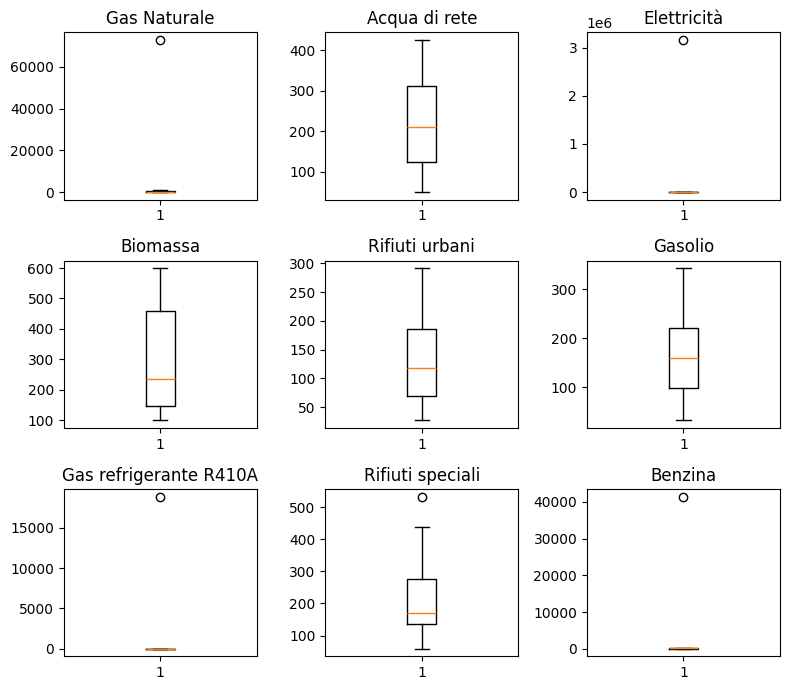

In [66]:
fig, axes = plt.subplots(3, 3, figsize=(8, 7))
axes = axes.flatten()

for i, risorsa in enumerate(df['Risorsa'].unique()):
    subset = df[df['Risorsa'] == risorsa]['Quantità']
    axes[i].boxplot(subset)
    axes[i].set_title(risorsa)

plt.tight_layout()
plt.show()

#### Resources analysed

Not all resources are treated equally. We selectively apply IQR removal to the four resources that showed visually anomalous extremes in the initial boxplots:

| Resource | Reason for inclusion |
|---|---|
| `Gas Naturale` | Long right tail — one or two very high consumption events |
| `Elettricità` | Wide spread across plants and seasons |
| `Gas refrigerante R410A` | High unit emission factor (GWP 2088) makes outliers extremely impactful |
| `Benzina` | Small sample size — a single anomalous entry could distort plant-level totals |

#### Resources excluded from IQR removal

**`Rifiuti speciali`** was deliberately excluded. Although a high value appeared in the boxplot, domain knowledge confirms it is plausible for this waste category and is not attributable to a data entry error. Removing it would undercount actual emissions. This distinction — between a statistical outlier and a genuine extreme value — is a judgment call that must be documented explicitly in any ESG audit trail.

All other resources (`Acqua di rete`, `Biomassa`, `Gasolio`, `Rifiuti urbani`) showed distributions consistent with expected operational variability and were left untouched.


In [67]:
risorse_da_filtrare = ['Gas Naturale', 'Elettricità', 'Gas refrigerante R410A', 'Benzina']
mask_bound = df['Risorsa'].isin(risorse_da_filtrare)

Q1 = df[mask_bound].groupby('Risorsa')['Quantità'].transform('quantile', 0.25)
Q3 = df[mask_bound].groupby('Risorsa')['Quantità'].transform('quantile', 0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask_out = mask_bound & (
    (df['Quantità'] < lower.reindex(df.index)) | 
    (df['Quantità'] > upper.reindex(df.index))
)

print(f"Outlier rimossi: {mask_out.sum()}")
df = df[~mask_out].reset_index(drop=True)

Outlier rimossi: 4


A second set of boxplots is generated after removal to confirm the result visually.

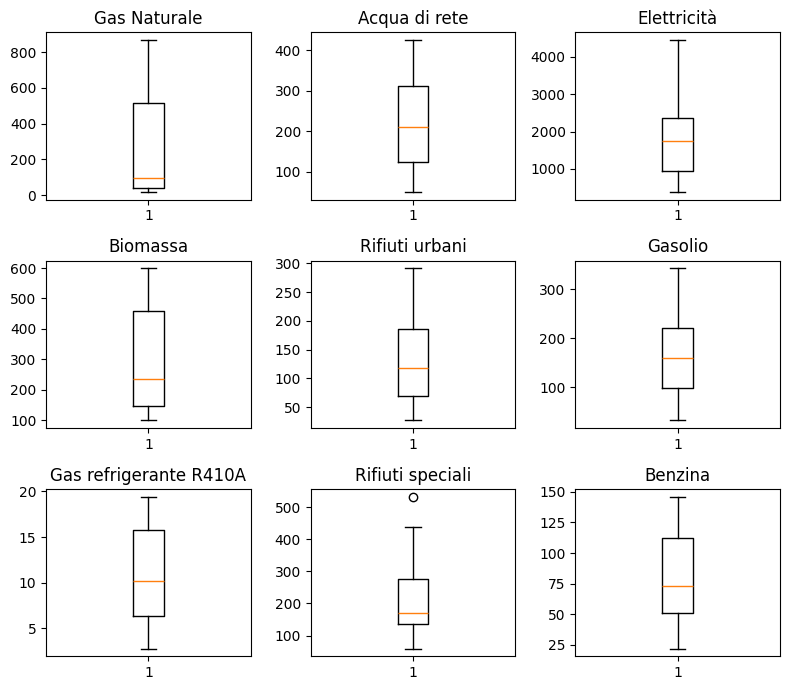

In [68]:
fig, axes = plt.subplots(3, 3, figsize=(8, 7))
axes = axes.flatten()

for i, risorsa in enumerate(df['Risorsa'].unique()):
    subset = df[df['Risorsa'] == risorsa]['Quantità']
    axes[i].boxplot(subset)
    axes[i].set_title(risorsa)

plt.tight_layout()
plt.show()

## Phase 3 — Emissions Calculation

With a clean, unified dataset in place, we can now apply **emission factors** to compute the CO₂-equivalent footprint of each consumption record.
An **emission factor (EF)** is a coefficient that converts a physical quantity of resource consumption into an equivalent mass of CO₂ (or CO₂-equivalent, CO₂e, when accounting for other greenhouse gases). The formula is simply:

```
Emissions (kgCO₂e) = Quantity × Emission Factor
```

Emission factors are not universal constants — they depend on the energy vector, the geographic context (especially for electricity), and the accounting methodology. Choosing the right factor for each resource is one of the most consequential decisions in an ESG calculation.


#### Emission Factors Used

Factors are centralised in `config.py` and split into two dictionaries to handle the location-dependency of electricity:

- `emission_factors` — for all resources except electricity
- `emission_factors_electricity` — electricity factors by city (Italy vs France)

| Resource | Factor | Unit | Source |
|---|---|---|---|
| Natural Gas | 0.202 | kgCO₂e / m³ | GHG Protocol / DEFRA 2024 |
| Diesel (Gasolio) | 0.267 | kgCO₂e / litre | GHG Protocol / DEFRA 2024 |
| Petrol (Benzina) | 0.249 | kgCO₂e / litre | GHG Protocol / DEFRA 2024 |
| Biomass | 0.0 | kgCO₂e / kg | ISPRA (cycle-neutral assumption) |
| Refrigerant R410A | 2088.0 | kgCO₂e / kg | GWP100, IPCC AR5 |
| Water supply | 0.149 | kgCO₂e / m³ | DEFRA 2024 |
| Special waste | 0.616 | kgCO₂e / kg | DEFRA 2024 |
| Municipal waste | 0.467 | kgCO₂e / kg | DEFRA 2024 |
| Electricity — IT (Milano, Roma) | 0.233 | kgCO₂e / kWh | ISPRA 2023 |
| Electricity — FR (Lione) | 0.052 | kgCO₂e / kWh | ADEME / RTE 2022–2024 |


#### Key methodological notes

**Biomass (0.0):** Biomass combustion is conventionally treated as carbon-neutral in national GHG inventories under the assumption that the CO₂ released during combustion was previously absorbed from the atmosphere during the plant's growth (closed carbon cycle). This is the ISPRA/IPCC convention for Scope 1 reporting. Note that this assumption has been contested in some contexts — its use should always be explicitly documented.

**Refrigerant R410A (GWP 2088):** Refrigerant leaks are classified as **fugitive emissions** — unintended releases that are not the result of combustion. R410A has an extremely high Global Warming Potential: each kilogram released to the atmosphere is equivalent to 2,088 kg of CO₂ over a 100-year horizon (GWP100). This makes even small quantities of refrigerant loss disproportionately significant in the total emission inventory. The GWP value used here is from IPCC AR5; note that IPCC AR6 revised this value slightly — which version to use depends on the reporting framework required by the disclosing company.

**Electricity — location-based method:** The Italian and French grids have very different carbon intensities. France's grid (0.052 kgCO₂e/kWh) is dominated by nuclear generation, making it roughly 4.5× cleaner than the Italian mix (0.233 kgCO₂e/kWh). This difference is captured by splitting `emission_factors_electricity` by city. The **location-based method** (using the average grid emission factor for the geographic location) is the reporting approach chosen.


In [69]:
df['Fattore emissione kgCO2/u'] = df['Risorsa'].map(emission_factors).fillna(df['Impianto'].map(emission_factors_electricity))

df

,Data,Categoria,Risorsa,Quantità,Unità,Impianto,Fattore emissione kgCO2/u
0,2024-01-03,Flotta aziendale,Gas Naturale,20.80,m3,Lione,0.202
1,2024-01-09,Acqua,Acqua di rete,103.28,m3,Lione,0.149
2,2024-01-15,Energia,Elettricità,2992.19,kWh,Lione,0.052
3,2024-01-23,Flotta aziendale,Gas Naturale,30.03,m3,Lione,0.202
4,2024-02-16,Riscaldamento,Gas Naturale,725.08,m3,Lione,0.202
...,...,...,...,...,...,...,...
295,2026-12-03,Raffreddamento,Gas refrigerante R410A,7.47,kg,Roma,2088.000
296,2026-12-14,Flotta aziendale,Benzina,53.50,Litri,Roma,0.249
297,2026-12-18,Rifiuti,Rifiuti speciali,427.56,kg,Roma,0.616
298,2026-12-21,Flotta aziendale,Benzina,113.91,Litri,Roma,0.249


In [70]:
df['Emissioni kgCO2'] = (df['Fattore emissione kgCO2/u']*df['Quantità']).round(2)

df

,Data,Categoria,Risorsa,Quantità,Unità,Impianto,Fattore emissione kgCO2/u,Emissioni kgCO2
0,2024-01-03,Flotta aziendale,Gas Naturale,20.80,m3,Lione,0.202,4.20
1,2024-01-09,Acqua,Acqua di rete,103.28,m3,Lione,0.149,15.39
2,2024-01-15,Energia,Elettricità,2992.19,kWh,Lione,0.052,155.59
3,2024-01-23,Flotta aziendale,Gas Naturale,30.03,m3,Lione,0.202,6.07
4,2024-02-16,Riscaldamento,Gas Naturale,725.08,m3,Lione,0.202,146.47
...,...,...,...,...,...,...,...,...
295,2026-12-03,Raffreddamento,Gas refrigerante R410A,7.47,kg,Roma,2088.000,15597.36
296,2026-12-14,Flotta aziendale,Benzina,53.50,Litri,Roma,0.249,13.32
297,2026-12-18,Rifiuti,Rifiuti speciali,427.56,kg,Roma,0.616,263.38
298,2026-12-21,Flotta aziendale,Benzina,113.91,Litri,Roma,0.249,28.36


In [71]:
print(df.groupby(['Impianto','Categoria'])['Emissioni kgCO2'].agg(['mean', 'sum', 'max', 'min']).round(2))

                               mean        sum       max     min
Impianto Categoria                                              
Lione    Acqua                31.72     475.83     61.83   10.89
         Energia             120.29    2526.07    197.80   61.80
         Flotta aziendale     22.38     313.32     53.92    4.20
         Raffreddamento    16524.32  280913.42  40590.72   24.85
         Rifiuti              77.50    1472.54    270.50   14.74
         Riscaldamento        49.64     893.54    153.29    0.00
Milano   Acqua                32.62     391.46     61.83    7.41
         Energia             555.98    8895.61   1037.23  326.46
         Flotta aziendale     18.48     221.82     54.72    3.39
         Raffreddamento     8768.27  201670.29  37500.48   89.05
         Rifiuti              94.97    1519.58    328.81   12.78
         Riscaldamento        49.40     740.97    131.88    0.00
Roma     Acqua                34.54     621.79     63.39   10.83
         Energia         

## Phase 4 — Export & Reporting

The final phase transforms the cleaned and enriched DataFrame into a **formatted, multi-sheet Excel report**.
The final workbook contains the following sheets:

| Sheet | Content |
|---|---|
| `Sintesi_Globale` | Pivot table: total kgCO₂e by plant × category × year, with grand totals |
| `Sintesi_Milano` | Same pivot, filtered to Milano only |
| `Sintesi_Lione` | Same pivot, filtered to Lione only |
| `Sintesi_Roma` | Same pivot, filtered to Roma only |
| `Dettaglio_emissioni` | Full row-level detail with all columns |

The summary sheets are placed first so the workbook opens to the most relevant view. The detail sheet serves as the audit trail — every number in the summaries can be traced back to a specific consumption record.


### Pivot table design

We use `pd.pivot_table()` to build the summary views before writing to Excel. Key design choices:

- **Index**: `['Impianto', 'Categoria']` — groups emissions by plant and energy category
- **Columns**: `'Anno'` — spreads years across columns for easy year-over-year comparison
- **Values**: `'Emissioni kgCO2'` — summed per group
- **`margins=True`**: adds a `'Totale'` row and column for grand totals
- **`fill_value=0`**: replaces `NaN` with 0 where a plant-category combination has no data in a given year

In [72]:
df['Anno'] = pd.to_datetime(df['Data']).dt.year

df_pivot = pd.pivot_table(df, values= 'Emissioni kgCO2', index=['Impianto', 'Categoria'], columns = 'Anno', aggfunc = 'sum', 
                          fill_value = 0, margins = True, margins_name = 'Totale').round(2).reset_index()
df_pivot

Anno,Impianto,Categoria,2024,2025,2026,Totale
0,Lione,Acqua,216.26,112.63,146.94,475.83
1,Lione,Energia,1031.51,678.59,815.97,2526.07
2,Lione,Flotta aziendale,29.34,119.45,164.53,313.32
3,Lione,Raffreddamento,135140.35,82548.43,63224.64,280913.42
4,Lione,Rifiuti,165.36,879.53,427.65,1472.54
5,Lione,Riscaldamento,209.28,516.26,168.00,893.54
6,Milano,Acqua,22.12,209.99,159.35,391.46
7,Milano,Energia,3131.41,2854.68,2909.52,8895.61
8,Milano,Flotta aziendale,134.94,43.04,43.84,221.82
9,Milano,Raffreddamento,54960.28,50670.11,96039.90,201670.29


### Formatting approach

Formatting is applied **after** data is written to Excel, using `openpyxl` to access the workbook object in memory via `writer.book`. This two-step pattern (pandas writes the data, openpyxl formats it) is applied.

Formatting rules applied:

- **Column widths** are auto-fitted based on the maximum content length in each column
- **Number format** `#,##0.00` is applied to all numeric cells (quantities, factors, emissions)
- **Date format** `DD/MM/YYYY` is applied to the `Data` column in the detail sheet
- **Alignment**: text columns left-aligned, numeric columns right-aligned — standard spreadsheet convention
- **Bold font** is applied to cells containing `'Totale'` and to the total column header, making them visually distinct from data rows

In [ ]:
# =========================
# WRITING AND FORMATTING
# =========================

with pd.ExcelWriter('output/report_finale.xlsx', engine='openpyxl') as writer:
    
    # Write the summary on the first sheet
    df_pivot.to_excel(writer, 'Sintesi_Globale', index=False)

    # Add one summary sheet for each IMPIANTO
    for impianto in df['Impianto'].unique():
        
        df_filtrato = df[df['Impianto'] == impianto]
        
        df_pivot_locale = pd.pivot_table(df_filtrato, values = 'Emissioni kgCO2', index=['Impianto', 'Categoria'], columns = 'Anno', aggfunc = 'sum', 
                          fill_value = 0, margins = True, margins_name = 'Totale').round(2).reset_index()
        
        nome_foglio = f'Sintesi_{impianto}'

        df_pivot_locale.to_excel(writer, nome_foglio, index = False)

    # Write the deatailed data on the last sheet
    df.to_excel(writer, 'Dettaglio_emissioni', index=False,
                columns=['Data', 'Categoria', 'Risorsa', 'Quantità', 'Unità', 'Fattore emissione kgCO2/u','Emissioni kgCO2', 'Impianto'])
    
    # Load the workbook and sheets into memory
    wb = writer.book
    ws_sintesi = writer.sheets['Sintesi_Globale']
    ws_dettaglio = writer.sheets['Dettaglio_emissioni']
    
    # Defining styles
    allineamento_sinistra = Alignment(horizontal='left', vertical='center')
    allineamento_destra = Alignment(horizontal='right', vertical='center')
    font_grassetto = Font(bold=True)
    
    # -----------------------------------
    # SHEET 1 FORMAT: OVERALL SUMMARY
    # -----------------------------------
    for col in ws_sintesi.columns:
        max_len = 0
        col_letter = get_column_letter(col[0].column)
        col_name = str(col[0].value)
        
        for cell in col:
            # Whether it is a header or a text column (System, Category)
            if cell.row == 1 or col_name in ['Impianto', 'Categoria']:
                cell.alignment = allineamento_sinistra
            else:
                # These are the years and totals: align to the right and format as a number
                cell.alignment = allineamento_destra
                cell.number_format = '#,##0.00'
                
            # Whether it is the Total row or the Total column, we put it in bold
            if cell.value == 'Totale' or ws_sintesi[f"{col_letter}1"].value == 'Totale':
                cell.font = font_grassetto
                
            if cell.value is not None:
                max_len = max(max_len, len(str(cell.value)))
        ws_sintesi.column_dimensions[col_letter].width = max(max_len + 3, 12)
        
    # ------------------------------------
    # SHEET 2 FORMAT: EMISSION DETAILS
    # ------------------------------------
    for col in ws_dettaglio.columns:
        col_letter = get_column_letter(col[0].column)
        col_name = col[0].value
        max_len = 0
        for cell in col:
            if cell.row == 1:
                cell.alignment = allineamento_sinistra
                stringa_valore = str(cell.value)
            else:
                if col_name == 'Data':
                    cell.alignment = allineamento_sinistra
                    cell.number_format = 'DD/MM/YYYY'
                    stringa_valore = "DD/MM/YYYY"
                elif col_name in ['Quantità', 'Fattore emissione kgCO2/u', 'Emissioni kgCO2']:
                    cell.alignment = allineamento_destra
                    cell.number_format = '#,##0.00'
                    stringa_valore = f"{cell.value:,.2f}" if cell.value is not None else ""
                else:
                    cell.alignment = allineamento_sinistra
                    stringa_valore = str(cell.value) if cell.value is not None else ""
            if cell.value is not None:
                max_len = max(max_len, len(stringa_valore))
        ws_dettaglio.column_dimensions[col_letter].width = max(max_len + 3, 12)


C:\Users\auror\AppData\Local\Temp\ipykernel_18212\462092525.py:8: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  df_pivot.to_excel(writer, 'Sintesi_Globale', index=False)
C:\Users\auror\AppData\Local\Temp\ipykernel_18212\462092525.py:19: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  df_pivot_locale.to_excel(writer, nome_foglio, index = False)
C:\Users\auror\AppData\Local\Temp\ipykernel_18212\462092525.py:19: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  df_pivot_locale.to_excel(writer, nome_foglio, index = False)
C:\Users\auror\AppData\Local\Temp\ipykernel_18212\462092525.py:19: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  df_pi